# 🛒 E-Commerce Sales Analytics — Olist Dataset

---

### Бизнес-вопросы которые мы решим:
1. Как растёт выручка компании по месяцам?
2. Какие категории товаров самые прибыльные?
3. Насколько быстро доставляем? Где проблемы?
4. Кто наши лучшие клиенты? (RFM-сегментация)
5. Что влияет на оценку клиента?

### Стек:
- **pandas, numpy** — обработка данных
- **SQLite + SQL** — аналитические запросы
- **matplotlib, seaborn** — визуализация
- **sklearn** — машинное обучение (кластеризация клиентов)

---

### Структура файлов датасета
Положи все CSV файлы в папку `data/` рядом с этим ноутбуком:
```
data/
  olist_orders_dataset.csv
  olist_order_items_dataset.csv
  olist_customers_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  product_category_name_translation.csv
```

---
## Блок 1: Установка библиотек и импорты


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')


---
## Блок 2: Загрузка данных


In [31]:
DATA_PATH = 'data/'

# Загружаем все таблицы
orders      = pd.read_csv(f'{DATA_PATH}olist_orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}olist_order_items_dataset.csv')
customers   = pd.read_csv(f'{DATA_PATH}olist_customers_dataset.csv')
products    = pd.read_csv(f'{DATA_PATH}olist_products_dataset.csv')
sellers     = pd.read_csv(f'{DATA_PATH}olist_sellers_dataset.csv')
payments    = pd.read_csv(f'{DATA_PATH}olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{DATA_PATH}olist_order_reviews_dataset.csv')
categories  = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

print('Размеры таблиц:')
tables = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'categories': categories
}
for name, df in tables.items():
    print(f'  {name:20s}: {df.shape[0]:>7,} строк × {df.shape[1]} колонок')

Размеры таблиц:
  orders              :  99,441 строк × 8 колонок
  order_items         : 112,650 строк × 7 колонок
  customers           :  99,441 строк × 5 колонок
  products            :  32,951 строк × 9 колонок
  sellers             :   3,095 строк × 4 колонок
  payments            : 103,886 строк × 5 колонок
  reviews             :  99,224 строк × 7 колонок
  categories          :      71 строк × 2 колонок


In [ ]:
print('Первые строки таблицы orders:')
orders.head()

Первые строки таблицы orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


---
## Блок 3: Очистка данных


In [ ]:
# Проверяем пропуски в orders
print('Пропуски в таблице orders:')
missing = orders.isnull().sum()
missing_pct = (missing / len(orders) * 100).round(2)
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
print(missing_df[missing_df['Пропусков'] > 0])

Пропуски в таблице orders:
                               Пропусков     %
order_approved_at                    160  0.16
order_delivered_carrier_date        1783  1.79
order_delivered_customer_date       2965  2.98


In [32]:
# Конвертируем даты из строки в формат datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Оставляем только доставленные заказы для основного анализа
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f'Всего заказов: {len(orders):,}')
print(f'Доставленных заказов: {len(orders_delivered):,}')
print(f'\nСтатусы заказов:')
print(orders['order_status'].value_counts())

Всего заказов: 99,441
Доставленных заказов: 96,478

Статусы заказов:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [33]:
# Добавляем полезные поля для анализа
# .astype(str) — конвертируем Period в строку '2017-01'
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)
orders_delivered['year'] = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['month'] = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['day_of_week'] = orders_delivered['order_purchase_timestamp'].dt.day_name()

# Считаем время доставки в днях
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_purchase_timestamp']
).dt.days

# Считаем задержку (отрицательное = доставили раньше срока)
orders_delivered['delivery_delay'] = (
    orders_delivered['order_delivered_customer_date'] - 
    orders_delivered['order_estimated_delivery_date']
).dt.days

print(orders_delivered[['year_month', 'delivery_days', 'delivery_delay']].describe())

       delivery_days  delivery_delay
count   96470.000000    96470.000000
mean       12.093604      -11.875889
std         9.551380       10.182105
min         0.000000     -147.000000
25%         6.000000      -17.000000
50%        10.000000      -12.000000
75%        15.000000       -7.000000
max       209.000000      188.000000


---
## Блок 4: Создаём базу данных SQLite


In [34]:
# Создаём файл базы данных
conn = sqlite3.connect('olist.db')

# Загружаем все таблицы в SQLite
for name, df in tables.items():
    df.to_sql(name, conn, if_exists='replace', index=False)
    print(f'✅ Загружена таблица: {name}')

# Также загружаем очищенные orders
orders_delivered.to_sql('orders_delivered', conn, if_exists='replace', index=False)
print('Загружена таблица: orders_delivered')
print('\n База данных olist.db создана!')

✅ Загружена таблица: orders
✅ Загружена таблица: order_items
✅ Загружена таблица: customers
✅ Загружена таблица: products
✅ Загружена таблица: sellers
✅ Загружена таблица: payments
✅ Загружена таблица: reviews
✅ Загружена таблица: categories
Загружена таблица: orders_delivered

 База данных olist.db создана!


In [35]:
# Вспомогательная функция для удобного выполнения SQL запросов
# Возвращает DataFrame
def sql(query):
    return pd.read_sql_query(query, conn)

# Проверка — смотрим список таблиц в базе
sql("SELECT name FROM sqlite_master WHERE type='table'")

,name
0,orders
1,order_items
2,customers
3,products
4,sellers
5,payments
6,reviews
7,categories
8,orders_delivered


---
## Блок 5: Анализ выручки — растёт ли бизнес?


In [36]:
# SQL запрос: выручка по месяцам
# JOIN соединяет таблицу заказов с платежами по order_id
# GROUP BY группирует строки по месяцу
# SUM считает суммарную выручку

revenue_monthly = sql("""
    SELECT 
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        COUNT(DISTINCT o.order_id)                    AS total_orders,
        ROUND(SUM(p.payment_value), 2)                AS total_revenue,
        ROUND(AVG(p.payment_value), 2)                AS avg_order_value
    FROM orders_delivered o
    JOIN payments p ON o.order_id = p.order_id
    WHERE strftime('%Y', o.order_purchase_timestamp) IN ('2017', '2018')
    GROUP BY month
    ORDER BY month
""")

print('Выручка по месяцам:')
revenue_monthly.tail(10)

Выручка по месяцам:


,month,total_orders,total_revenue,avg_order_value
2,2017-09,4150,701169.99,160.41
3,2017-10,4478,751140.27,159.89
4,2017-11,7289,1153528.05,151.92
5,2017-12,5513,843199.17,147.18
6,2018-02,8208,1237809.53,145.20
7,2018-03,9549,1535047.39,153.55
8,2018-04,9101,1523886.13,160.36
9,2018-06,9234,1502316.28,155.31
10,2018-07,10031,1594307.79,151.59
11,2018-08,10544,1631414.89,149.29


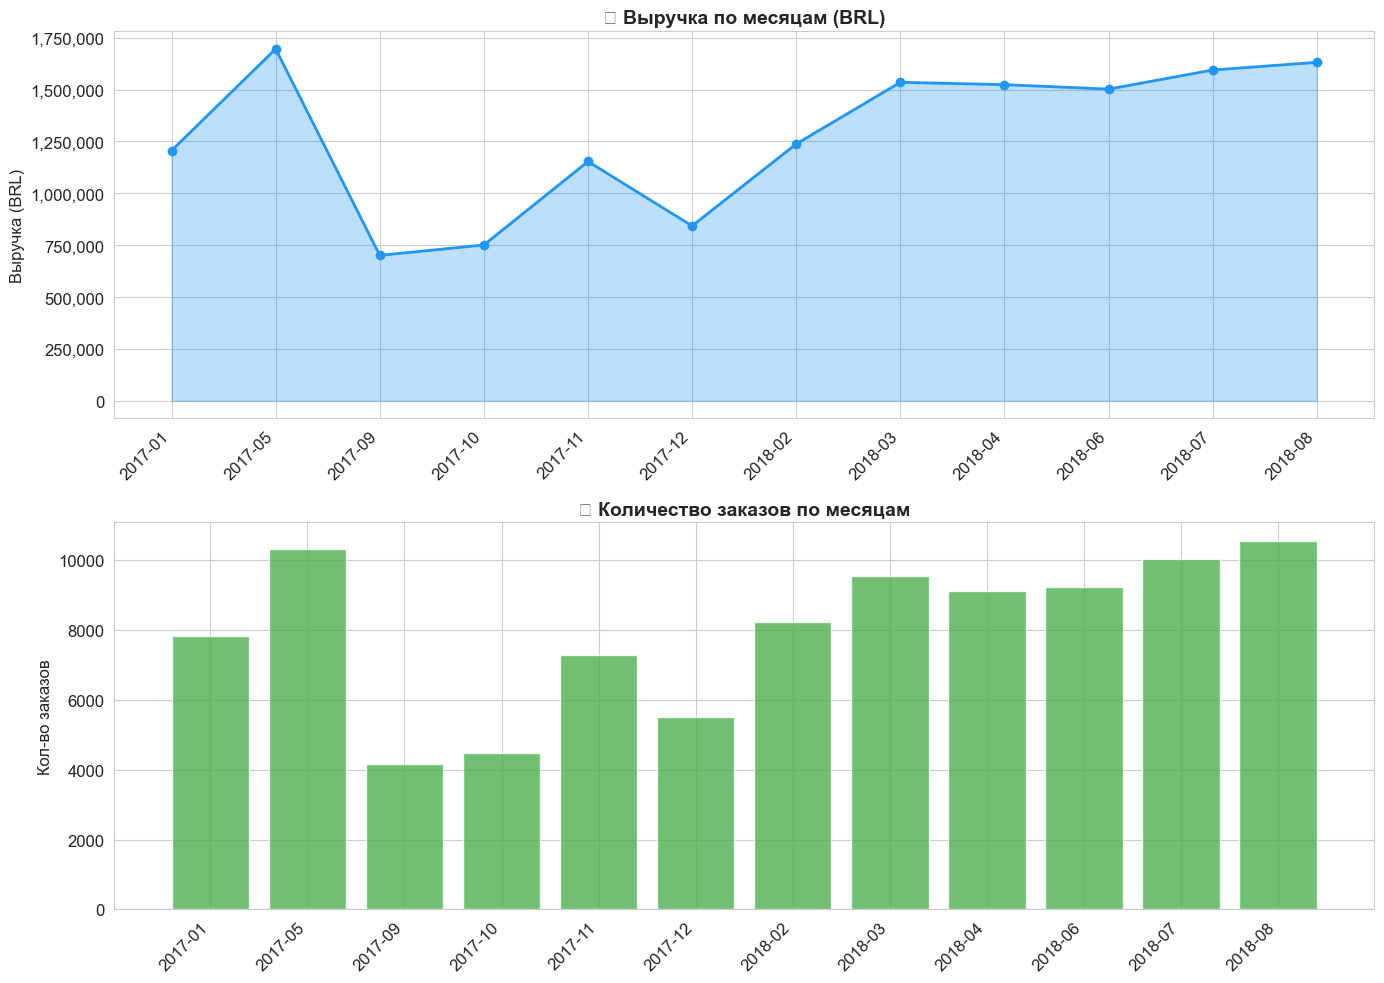


ВЫВОД:
Выручка выросла с 701,170 до 1,695,903 BRL
Рост за период: +141.9%
Средний чек: 153.32 BRL


In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Выручка
axes[0].fill_between(range(len(revenue_monthly)), revenue_monthly['total_revenue'], alpha=0.3, color='#2196F3')
axes[0].plot(range(len(revenue_monthly)), revenue_monthly['total_revenue'], 'o-', color='#2196F3', linewidth=2)
axes[0].set_xticks(range(len(revenue_monthly)))
axes[0].set_xticklabels(revenue_monthly['month'], rotation=45, ha='right')
axes[0].set_title('💰 Выручка по месяцам (BRL)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Выручка (BRL)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# График 2: Количество заказов
axes[1].bar(range(len(revenue_monthly)), revenue_monthly['total_orders'], color='#4CAF50', alpha=0.8)
axes[1].set_xticks(range(len(revenue_monthly)))
axes[1].set_xticklabels(revenue_monthly['month'], rotation=45, ha='right')
axes[1].set_title('📦 Количество заказов по месяцам', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Кол-во заказов')

plt.tight_layout()
plt.savefig('charts/01_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Бизнес-вывод
max_rev = revenue_monthly['total_revenue'].max()
min_rev = revenue_monthly['total_revenue'].min()
growth = ((max_rev - min_rev) / min_rev * 100).round(1)
print(f'\nВЫВОД:')
print(f'Выручка выросла с {min_rev:,.0f} до {max_rev:,.0f} BRL')
print(f'Рост за период: +{growth}%')
print(f'Средний чек: {revenue_monthly["avg_order_value"].mean():.2f} BRL')

---
## Блок 6: Анализ категорий товаров

In [38]:
# Здесь мы делаем JOIN сразу 4 таблиц — это типичный запрос аналитика
# Каждый JOIN добавляет новую информацию к результату

category_revenue = sql("""
    SELECT 
        c.product_category_name_english  AS category,
        COUNT(DISTINCT oi.order_id)      AS total_orders,
        ROUND(SUM(oi.price), 2)          AS total_revenue,
        ROUND(AVG(oi.price), 2)          AS avg_price,
        COUNT(oi.product_id)             AS items_sold
    FROM order_items oi
    JOIN orders_delivered o  ON oi.order_id = o.order_id
    JOIN products p          ON oi.product_id = p.product_id
    JOIN categories c        ON p.product_category_name = c.product_category_name
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 15
""")

category_revenue

,category,total_orders,total_revenue,avg_price,items_sold
0,health_beauty,8647,1233131.72,130.28,9465
1,watches_gifts,5495,1166176.98,199.04,5859
2,bed_bath_table,9272,1023434.76,93.44,10953
3,sports_leisure,7530,954852.55,113.25,8431
4,computers_accessories,6530,888724.61,116.26,7644
5,furniture_decor,6307,711927.69,87.25,8160
6,housewares,5743,615628.69,90.60,6795
7,cool_stuff,3559,610204.10,164.12,3718
8,auto,3810,578966.65,139.85,4140
9,toys,3804,471286.48,116.94,4030


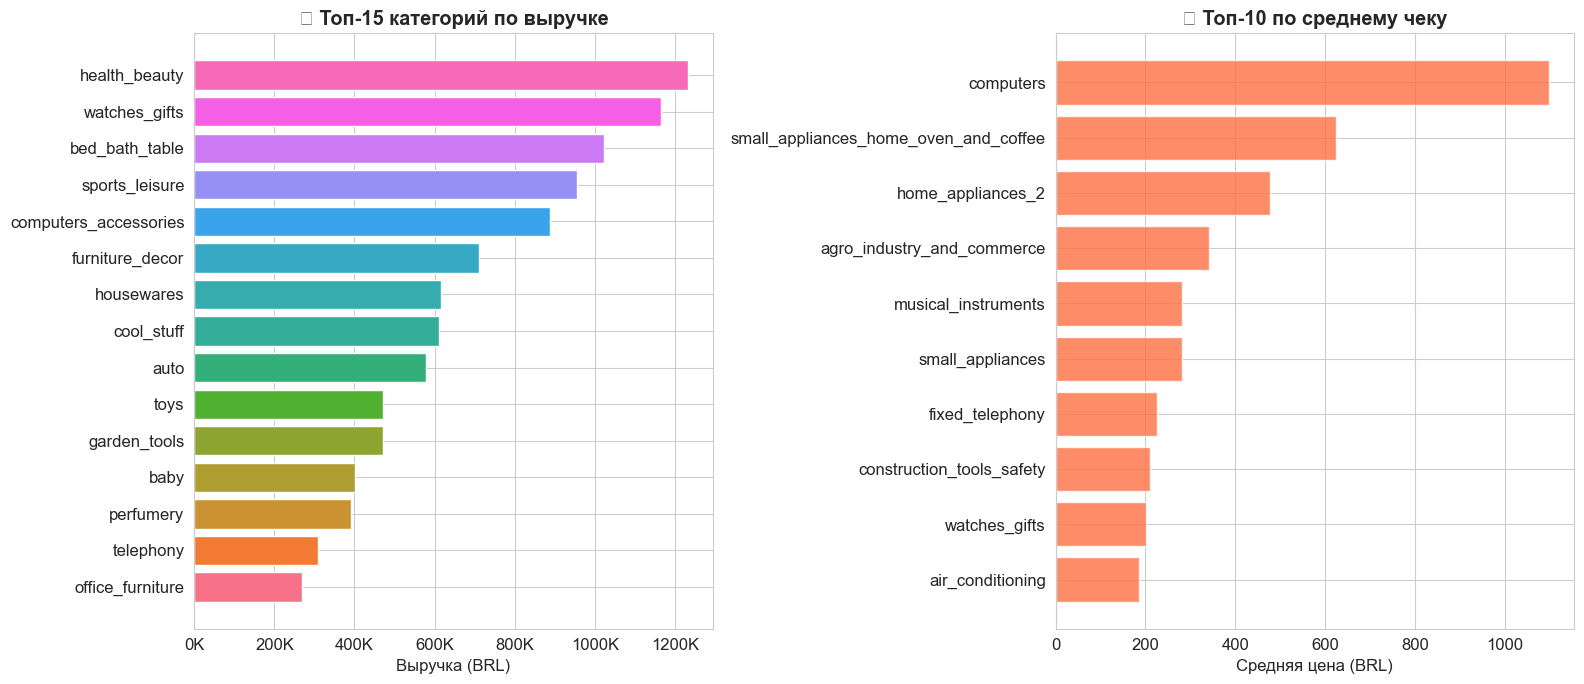

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Топ категории по выручке
colors = sns.color_palette('husl', 15)
bars = axes[0].barh(category_revenue['category'][::-1], 
                    category_revenue['total_revenue'][::-1], 
                    color=colors)
axes[0].set_title('🏆 Топ-15 категорий по выручке', fontweight='bold')
axes[0].set_xlabel('Выручка (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Топ категории по среднему чеку
top_avg = sql("""
    SELECT 
        c.product_category_name_english AS category,
        ROUND(AVG(oi.price), 2)         AS avg_price
    FROM order_items oi
    JOIN products p   ON oi.product_id = p.product_id
    JOIN categories c ON p.product_category_name = c.product_category_name
    GROUP BY category
    HAVING COUNT(*) > 50
    ORDER BY avg_price DESC
    LIMIT 10
""")
axes[1].barh(top_avg['category'][::-1], top_avg['avg_price'][::-1], color='#FF7043', alpha=0.8)
axes[1].set_title('💎 Топ-10 по среднему чеку', fontweight='bold')
axes[1].set_xlabel('Средняя цена (BRL)')

plt.tight_layout()
plt.savefig('charts/02_categories.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 7: Анализ доставки


In [39]:
# Статистика по доставке
delivery_stats = sql("""
    SELECT 
        ROUND(AVG(delivery_days), 1)                AS avg_delivery_days,
        ROUND(MIN(delivery_days), 1)                AS min_delivery_days,
        ROUND(MAX(delivery_days), 1)                AS max_delivery_days,
        ROUND(AVG(delivery_delay), 1)               AS avg_delay_days,
        COUNT(CASE WHEN delivery_delay > 0 THEN 1 END) * 100.0 / COUNT(*) AS late_pct
    FROM orders_delivered
    WHERE delivery_days IS NOT NULL
""")

print(' Статистика доставки:')
print(f'  Среднее время доставки: {delivery_stats["avg_delivery_days"][0]} дней')
print(f'  Минимальное: {delivery_stats["min_delivery_days"][0]} дней')
print(f'  Максимальное: {delivery_stats["max_delivery_days"][0]} дней')
print(f'  Средняя задержка: {delivery_stats["avg_delay_days"][0]} дней')
print(f'  Процент опозданий: {delivery_stats["late_pct"][0]:.1f}%')

 Статистика доставки:
  Среднее время доставки: 12.1 дней
  Минимальное: 0.0 дней
  Максимальное: 209.0 дней
  Средняя задержка: -11.9 дней
  Процент опозданий: 6.8%


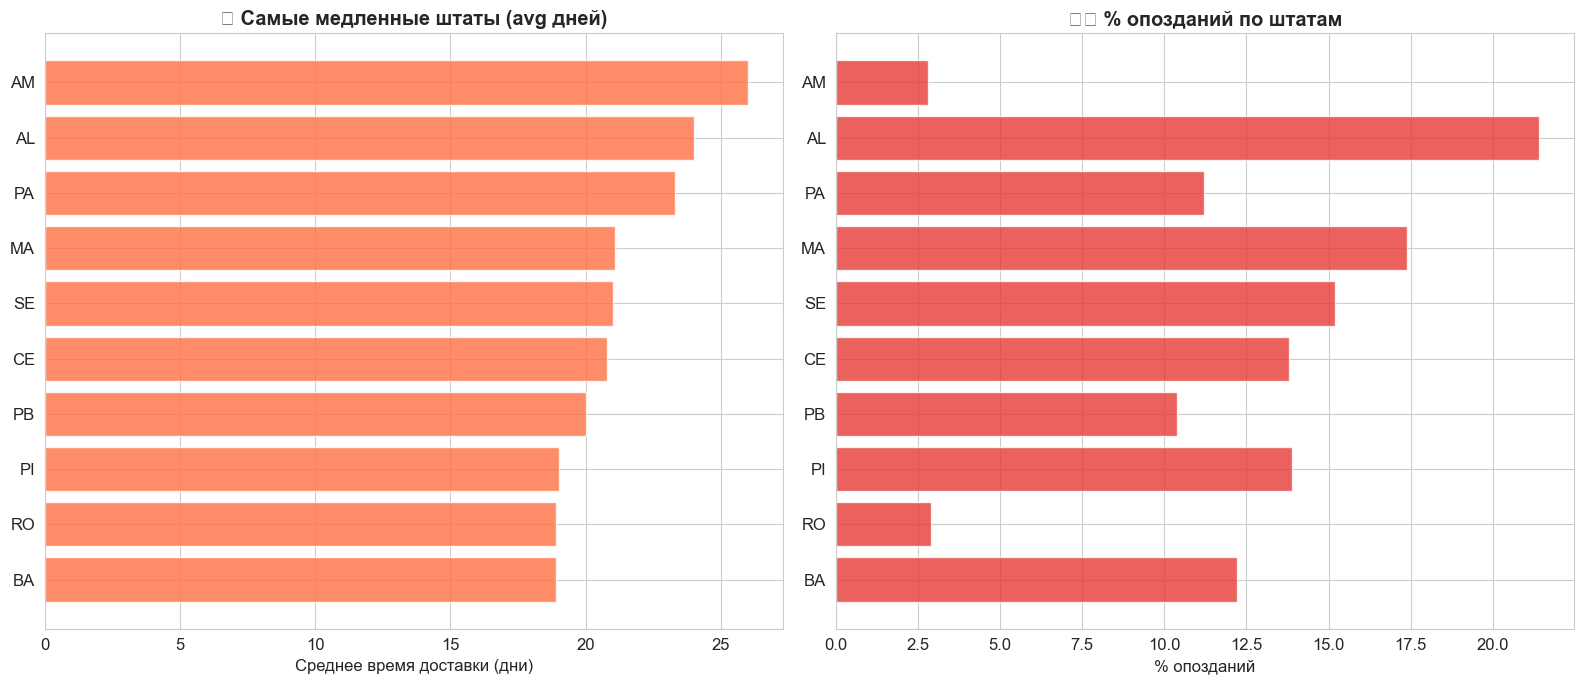

In [ ]:
# Доставка по штатам 
delivery_by_state = sql("""
    SELECT 
        c.customer_state                            AS state,
        COUNT(*)                                    AS total_orders,
        ROUND(AVG(o.delivery_days), 1)              AS avg_delivery_days,
        ROUND(AVG(o.delivery_delay), 1)             AS avg_delay,
        ROUND(COUNT(CASE WHEN o.delivery_delay > 0 THEN 1 END) * 100.0 / COUNT(*), 1) AS late_pct
    FROM orders_delivered o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.delivery_days IS NOT NULL
    GROUP BY state
    HAVING total_orders > 100
    ORDER BY avg_delivery_days DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Топ штатов по времени доставки
top10 = delivery_by_state.head(10)
colors_map = ['#f44336' if x > 0 else '#4CAF50' for x in top10['avg_delay']]
axes[0].barh(top10['state'][::-1], top10['avg_delivery_days'][::-1], color='#FF7043', alpha=0.8)
axes[0].set_title('🐢 Самые медленные штаты (avg дней)', fontweight='bold')
axes[0].set_xlabel('Среднее время доставки (дни)')

# Процент опозданий
axes[1].barh(top10['state'][::-1], top10['late_pct'][::-1], color='#E53935', alpha=0.8)
axes[1].set_title('⚠️ % опозданий по штатам', fontweight='bold')
axes[1].set_xlabel('% опозданий')

plt.tight_layout()
plt.savefig('charts/03_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

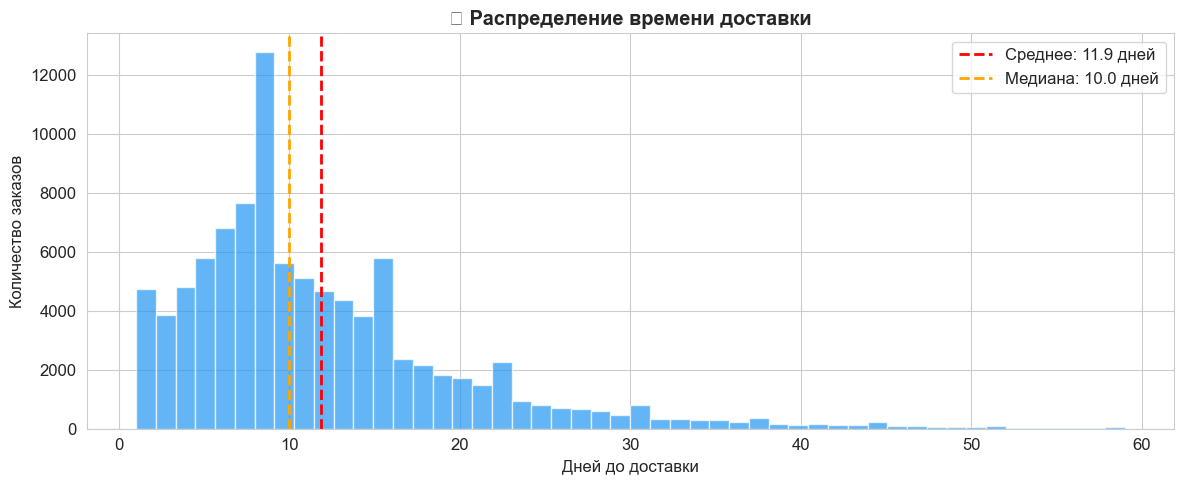

In [ ]:
# Распределение времени доставки — histogram
# Это показывает типичный заказ
delivery_data = orders_delivered['delivery_days'].dropna()
delivery_data = delivery_data[(delivery_data > 0) & (delivery_data < 60)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(delivery_data, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(delivery_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {delivery_data.mean():.1f} дней')
ax.axvline(delivery_data.median(), color='orange', linestyle='--', linewidth=2, label=f'Медиана: {delivery_data.median():.1f} дней')
ax.set_title('📊 Распределение времени доставки', fontweight='bold')
ax.set_xlabel('Дней до доставки')
ax.set_ylabel('Количество заказов')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_delivery_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 8: RFM-сегментация клиентов


**RFM — классический метод сегментации в e-commerce:**
- **R**ecency — как давно клиент делал покупку? (чем свежее — тем лучше)
- **F**requency — как часто покупает? (чем чаще — тем лучше)
- **M**onetary — сколько денег потратил? (чем больше — тем лучше)

**Результат:** делим клиентов на сегменты — Champions, Loyal, At Risk и т.д.

In [ ]:
# SQL запрос для расчёта RFM метрик
# reference_date — самая поздняя дата в датасете, считаем с неё
rfm_raw = sql("""
    WITH reference_date AS (
        SELECT DATE(MAX(order_purchase_timestamp)) AS ref_date
        FROM orders_delivered
    )
    SELECT 
        o.customer_id,
        -- Recency: сколько дней прошло с последней покупки
        CAST(julianday((SELECT ref_date FROM reference_date)) - 
             julianday(MAX(o.order_purchase_timestamp)) AS INTEGER) AS recency,
        -- Frequency: количество заказов
        COUNT(DISTINCT o.order_id) AS frequency,
        -- Monetary: общая сумма
        ROUND(SUM(p.payment_value), 2) AS monetary
    FROM orders_delivered o
    JOIN payments p ON o.order_id = p.order_id
    GROUP BY o.customer_id
""")

print(f'Клиентов для RFM анализа: {len(rfm_raw):,}')
print()
rfm_raw.describe().round(2)

Клиентов для RFM анализа: 96,477



,recency,frequency,monetary
count,96477.00,96477.0,96477.00
mean,238.65,1.0,159.86
std,152.83,0.0,218.81
min,0.00,1.0,9.59
25%,115.00,1.0,61.88
50%,220.00,1.0,105.28
75%,348.00,1.0,176.33
max,694.00,1.0,13664.08


In [19]:
# Присваиваем каждому клиенту RFM скоры от 1 до 5
# qcut делит клиентов на 5 равных групп по каждой метрике
# Для Recency: меньше дней = лучше (поэтому labels перевёрнуты)

rfm = rfm_raw.copy()

# R score: 5 = покупал недавно (хорошо), 1 = давно (плохо)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)

# F score: 5 = много покупок (хорошо)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# M score: 5 = потратил много (хорошо)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)

# Итоговый RFM скор (среднее)
rfm['RFM_score'] = (rfm['R_score'] + rfm['F_score'] + rfm['M_score']) / 3

# Сегментируем клиентов
def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'        # Лучшие клиенты
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'  # Лояльные
    elif r >= 4 and f <= 2:
        return 'New Customers'    # Новые
    elif r <= 2 and f >= 3:
        return 'At Risk'          # Уходящие
    elif r <= 2 and f <= 2:
        return 'Lost'             # Потерянные
    else:
        return 'Potential'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print('Распределение по сегментам:')
seg_counts = rfm['segment'].value_counts()
for seg, cnt in seg_counts.items():
    print(f'  {seg:20s}: {cnt:,} клиентов ({cnt/len(rfm)*100:.1f}%)')

Распределение по сегментам:
  Loyal Customers     : 28,365 клиентов (29.4%)
  At Risk             : 23,181 клиентов (24.0%)
  New Customers       : 15,551 клиентов (16.1%)
  Lost                : 15,267 клиентов (15.8%)
  Potential           : 7,773 клиентов (8.1%)
  Champions           : 6,340 клиентов (6.6%)


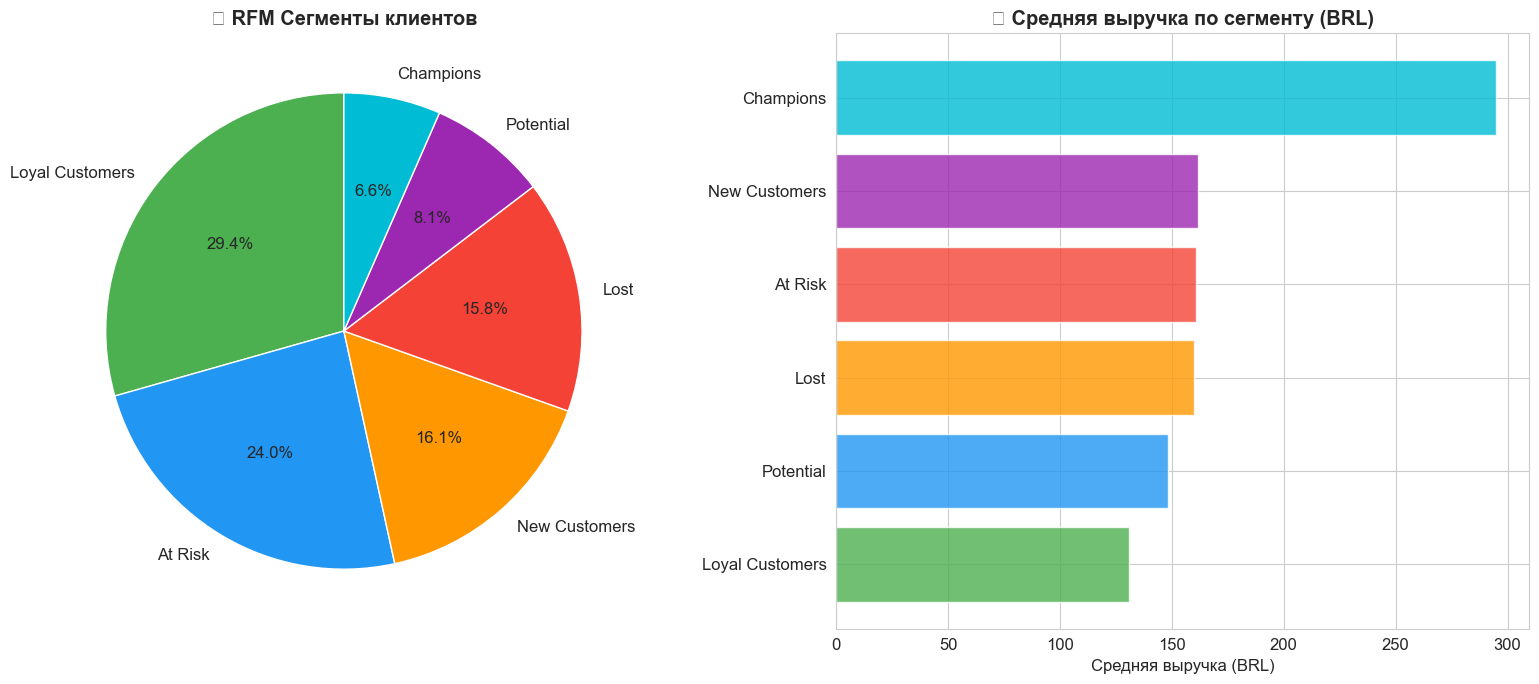


 Детальная статистика по сегментам:


,recency,frequency,monetary
segment,,,
At Risk,396.19,1.0,160.85
Champions,91.55,1.0,294.90
Lost,395.74,1.0,159.98
Loyal Customers,144.02,1.0,130.90
New Customers,90.59,1.0,161.78
Potential,221.83,1.0,148.32


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart сегментов
seg_data = rfm['segment'].value_counts()
colors_seg = ['#4CAF50', '#2196F3', '#FF9800', '#f44336', '#9C27B0', '#00BCD4']
axes[0].pie(seg_data.values, labels=seg_data.index, autopct='%1.1f%%', 
            colors=colors_seg[:len(seg_data)], startangle=90)
axes[0].set_title('👥 RFM Сегменты клиентов', fontweight='bold')

# Средняя выручка по сегментам
seg_revenue = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=True)
axes[1].barh(seg_revenue.index, seg_revenue.values, color=colors_seg[:len(seg_revenue)], alpha=0.8)
axes[1].set_title('💰 Средняя выручка по сегменту (BRL)', fontweight='bold')
axes[1].set_xlabel('Средняя выручка (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('charts/05_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Детальная статистика по сегментам:')
rfm.groupby('segment')[['recency', 'frequency', 'monetary']].mean().round(2)

---
## Блок 9: K-Means кластеризация (Machine Learning)


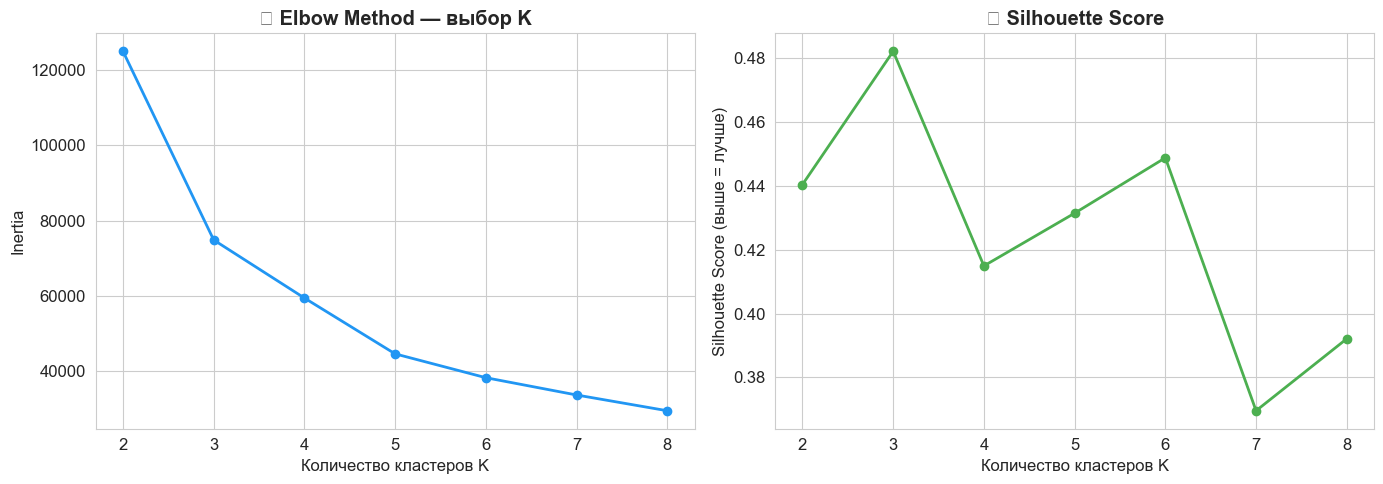


Выбираем K где кривая делает «локоть» (elbow) — обычно 3-5


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Берём RFM признаки
X = rfm[['recency', 'frequency', 'monetary']].copy()

# Масштабируем данные 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method 
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='#2196F3', linewidth=2)
axes[0].set_title('Elbow Method — выбор K', fontweight='bold')
axes[0].set_xlabel('Количество кластеров K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'o-', color='#4CAF50', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Количество кластеров K')
axes[1].set_ylabel('Silhouette Score (выше = лучше)')

plt.tight_layout()
plt.savefig('charts/06_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nВыбираем K где кривая делает локоть (elbow) обычно 3-5')

In [44]:
# Финальная модель с K=4
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

# Анализируем кластеры 
cluster_profile = rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(2)
cluster_profile['count'] = rfm['cluster'].value_counts().sort_index()
print('Профиль кластеров:')
print(cluster_profile)

cluster_names = {
    cluster_profile['monetary'].idxmax(): 'VIP Клиенты',
    cluster_profile['recency'].idxmin(): 'Новые Активные',
    cluster_profile['recency'].idxmax(): 'Ушедшие клиенты ',
}
# Остальной кластер - средний
for i in range(K_OPTIMAL):
    if i not in cluster_names:
        cluster_names[i] = 'Средний сегмент '

rfm['cluster_name'] = rfm['cluster'].map(cluster_names)
print('\nНазвания кластеров:')
print(rfm['cluster_name'].value_counts())

Профиль кластеров:
         recency  frequency  monetary  count
cluster                                     
0         253.73        1.0    130.10  35684
1         456.61        1.0    131.80  22481
2         239.68        1.0   1120.99   2621
3          86.21        1.0    136.70  35691

Названия кластеров:
cluster_name
Новые Активные      35691
Средний сегмент     35684
Ушедшие клиенты     22481
VIP Клиенты          2621
Name: count, dtype: int64


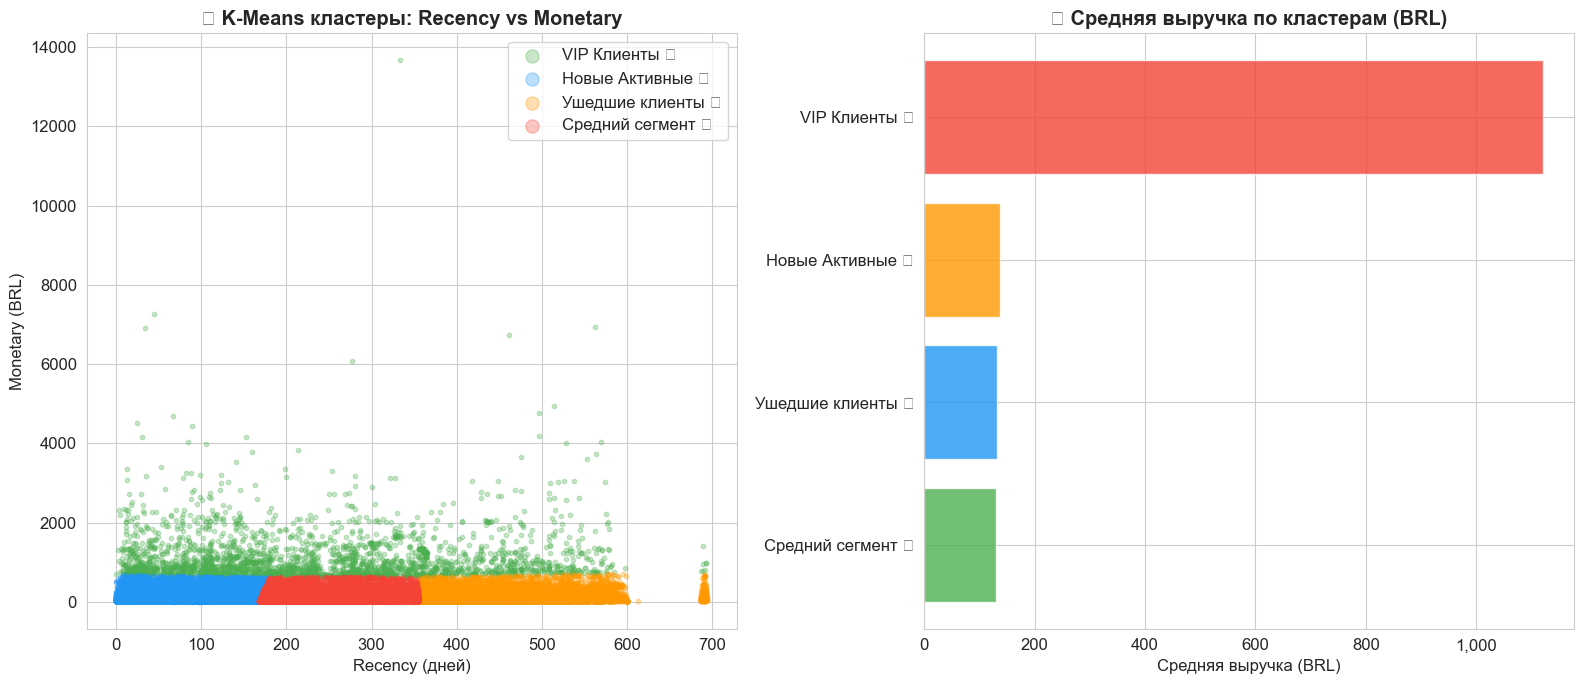

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors_k = ['#4CAF50', '#2196F3', '#FF9800', '#f44336']

# Scatter: Recency vs Monetary
for i, (cluster, name) in enumerate(cluster_names.items()):
    mask = rfm['cluster'] == cluster
    axes[0].scatter(
        rfm[mask]['recency'], 
        rfm[mask]['monetary'],
        alpha=0.3, s=10, color=colors_k[i], label=name
    )
axes[0].set_xlabel('Recency (дней)')
axes[0].set_ylabel('Monetary (BRL)')
axes[0].set_title('K-Means кластеры: Recency vs Monetary', fontweight='bold')
axes[0].legend(markerscale=3)

# Bar: средняя выручка по кластерам
cluster_rev = rfm.groupby('cluster_name')['monetary'].mean().sort_values(ascending=True)
axes[1].barh(cluster_rev.index, cluster_rev.values, 
             color=[colors_k[i] for i in range(len(cluster_rev))], alpha=0.8)
axes[1].set_title(' Средняя выручка по кластерам (BRL)', fontweight='bold')
axes[1].set_xlabel('Средняя выручка (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('charts/07_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Блок 10: Анализ отзывов


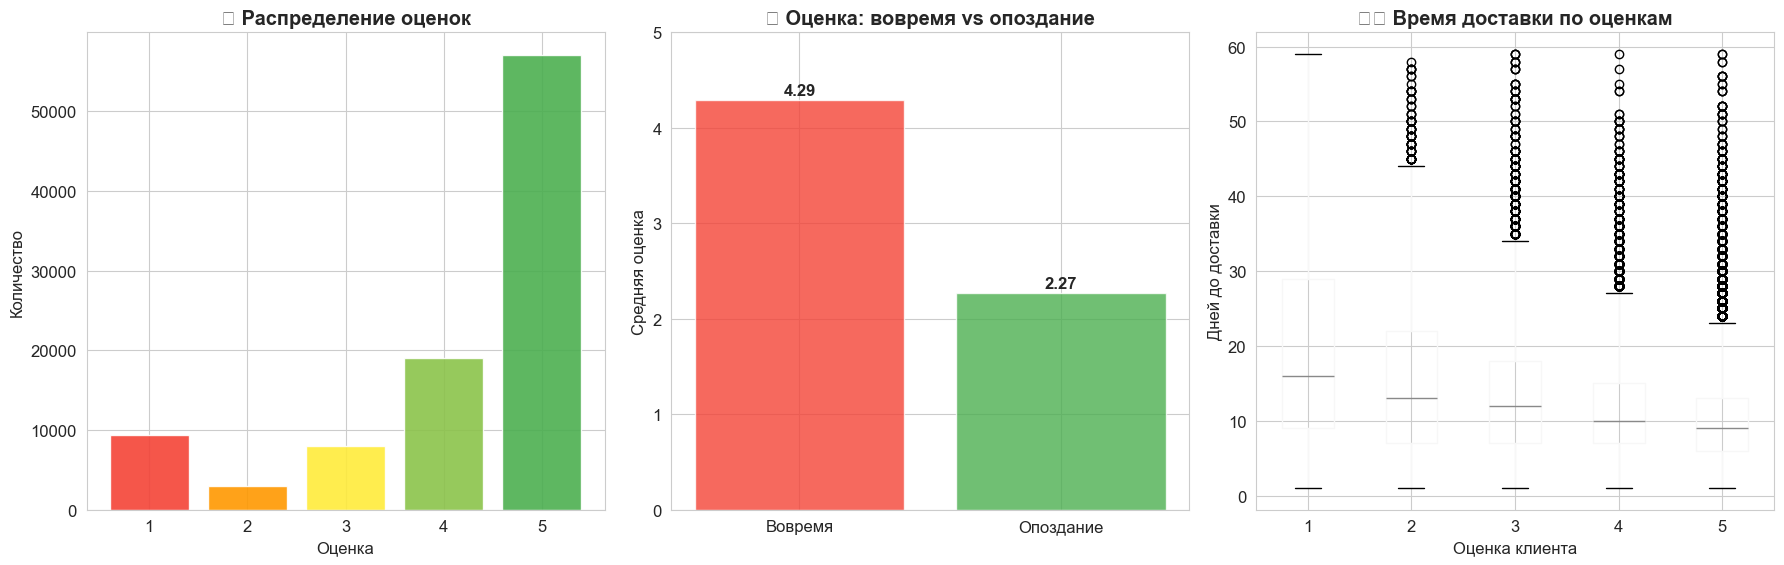


Средняя оценка (доставлено вовремя): 4.29
Средняя оценка (с опозданием): 2.27
Разница: 2.02 балла

ВЫВОД: Гипотеза подтверждена опоздание снижает оценку на 2.02 балла


In [47]:
# Соединяем отзывы с данными о доставке
review_analysis = sql("""
    SELECT 
        r.review_score,
        o.delivery_days,
        o.delivery_delay,
        CASE WHEN o.delivery_delay > 0 THEN 'Опоздание' ELSE 'Вовремя' END AS delivery_status
    FROM reviews r
    JOIN orders_delivered o ON r.order_id = o.order_id
    WHERE o.delivery_days IS NOT NULL
      AND r.review_score IS NOT NULL
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Распределение оценок
score_counts = review_analysis['review_score'].value_counts().sort_index()
colors_score = ['#f44336', '#FF9800', '#FFEB3B', '#8BC34A', '#4CAF50']
axes[0].bar(score_counts.index, score_counts.values, color=colors_score, alpha=0.9)
axes[0].set_title('⭐ Распределение оценок', fontweight='bold')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество')

# Средняя оценка: вовремя, опоздание
delivery_score = review_analysis.groupby('delivery_status')['review_score'].mean()
bars = axes[1].bar(delivery_score.index, delivery_score.values, 
                   color=['#f44336', '#4CAF50'], alpha=0.8)
axes[1].set_ylim(0, 5)
axes[1].set_title('📦 Оценка: вовремя vs опоздание', fontweight='bold')
axes[1].set_ylabel('Средняя оценка')
for bar, val in zip(bars, delivery_score.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{val:.2f}', ha='center', fontweight='bold')

# Boxplot: оценка vs время доставки
review_analysis_clean = review_analysis[(review_analysis['delivery_days'] > 0) & 
                                         (review_analysis['delivery_days'] < 60)]
review_analysis_clean.boxplot(column='delivery_days', by='review_score', ax=axes[2])
axes[2].set_title('⏱️ Время доставки по оценкам', fontweight='bold')
axes[2].set_xlabel('Оценка клиента')
axes[2].set_ylabel('Дней до доставки')
plt.suptitle('')  

plt.tight_layout()
plt.savefig('charts/08_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

# Проверка гипотезы
on_time_score = review_analysis[review_analysis['delivery_status']=='Вовремя']['review_score'].mean()
late_score = review_analysis[review_analysis['delivery_status']=='Опоздание']['review_score'].mean()
print(f'\nСредняя оценка (доставлено вовремя): {on_time_score:.2f}')
print(f'Средняя оценка (с опозданием): {late_score:.2f}')
print(f'Разница: {on_time_score - late_score:.2f} балла')
print(f'\nВЫВОД: Гипотеза подтверждена опоздание снижает оценку на {on_time_score - late_score:.2f} балла')

---
## Блок 11: Продвинутый SQL


In [48]:
running_total = sql("""
    WITH monthly AS (
        SELECT 
            strftime('%Y-%m', o.order_purchase_timestamp) AS month,
            ROUND(SUM(p.payment_value), 2) AS revenue
        FROM orders_delivered o
        JOIN payments p ON o.order_id = p.order_id
        WHERE strftime('%Y', o.order_purchase_timestamp) IN ('2017', '2018')
        GROUP BY month
    )
    SELECT 
        month,
        revenue,
        -- Running total: нарастающая сумма
        SUM(revenue) OVER (ORDER BY month) AS running_total,
        -- Month-over-month рост
        ROUND((revenue - LAG(revenue) OVER (ORDER BY month)) / 
              LAG(revenue) OVER (ORDER BY month) * 100, 1) AS mom_growth_pct
    FROM monthly
""")

print('Running total и MoM рост:')
running_total

Running total и MoM рост:


,month,revenue,running_total,mom_growth_pct
0,2017-01,1206152.53,1206152.53,NaN
1,2017-05,1695903.42,2902055.95,40.6
2,2017-09,701169.99,3603225.94,-58.7
3,2017-10,751140.27,4354366.21,7.1
4,2017-11,1153528.05,5507894.26,53.6
5,2017-12,843199.17,6351093.43,-26.9
6,2018-02,1237809.53,7588902.96,46.8
7,2018-03,1535047.39,9123950.35,24.0
8,2018-04,1523886.13,10647836.48,-0.7
9,2018-06,1502316.28,12150152.76,-1.4


In [26]:
# ВАЖНО: SQLite не разрешает фильтровать по алиасу оконной функции в WHERE
# Решение — оборачиваем результат в ещё один CTE и фильтруем снаружи

seller_ranking = sql("""
    WITH seller_revenue AS (
        SELECT 
            oi.seller_id,
            c.product_category_name_english AS category,
            ROUND(SUM(oi.price), 2) AS revenue,
            COUNT(*) AS items_sold
        FROM order_items oi
        JOIN orders_delivered o  ON oi.order_id = o.order_id
        JOIN products p          ON oi.product_id = p.product_id
        JOIN categories c        ON p.product_category_name = c.product_category_name
        GROUP BY oi.seller_id, category
    ),
    ranked AS (
        SELECT 
            seller_id,
            category,
            revenue,
            items_sold,
            RANK() OVER (PARTITION BY category ORDER BY revenue DESC) AS rank_in_category
        FROM seller_revenue
        WHERE category IN ('health_beauty', 'computers_accessories', 'watches_gifts')
    )
    SELECT * FROM ranked
    WHERE rank_in_category <= 3
    ORDER BY category, rank_in_category
""")

print('Топ-3 продавца в каждой категории:')
seller_ranking


Топ-3 продавца в каждой категории:


,seller_id,category,revenue,items_sold,rank_in_category
0,25c5c91f63607446a97b143d2d535d31,computers_accessories,52787.08,259,1
1,de722cd6dad950a92b7d4f82673f8833,computers_accessories,51898.00,360,2
2,a1043bafd471dff536d0c462352beb48,computers_accessories,45620.56,332,3
3,edb1ef5e36e0c8cd84eb3c9b003e486d,health_beauty,79144.90,174,1
4,ccc4bbb5f32a6ab2b7066a4130f114e3,health_beauty,71393.83,184,2
5,f7ba60f8c3f99e7ee4042fdef03b70c4,health_beauty,65492.00,200,3
6,4869f7a5dfa277a7dca6462dcf3b52b2,watches_gifts,198822.03,995,1
7,fa1c13f2614d7b5c4749cbc52fecda94,watches_gifts,188967.85,572,2
8,7e93a43ef30c4f03f38b393420bc753a,watches_gifts,160087.66,298,3


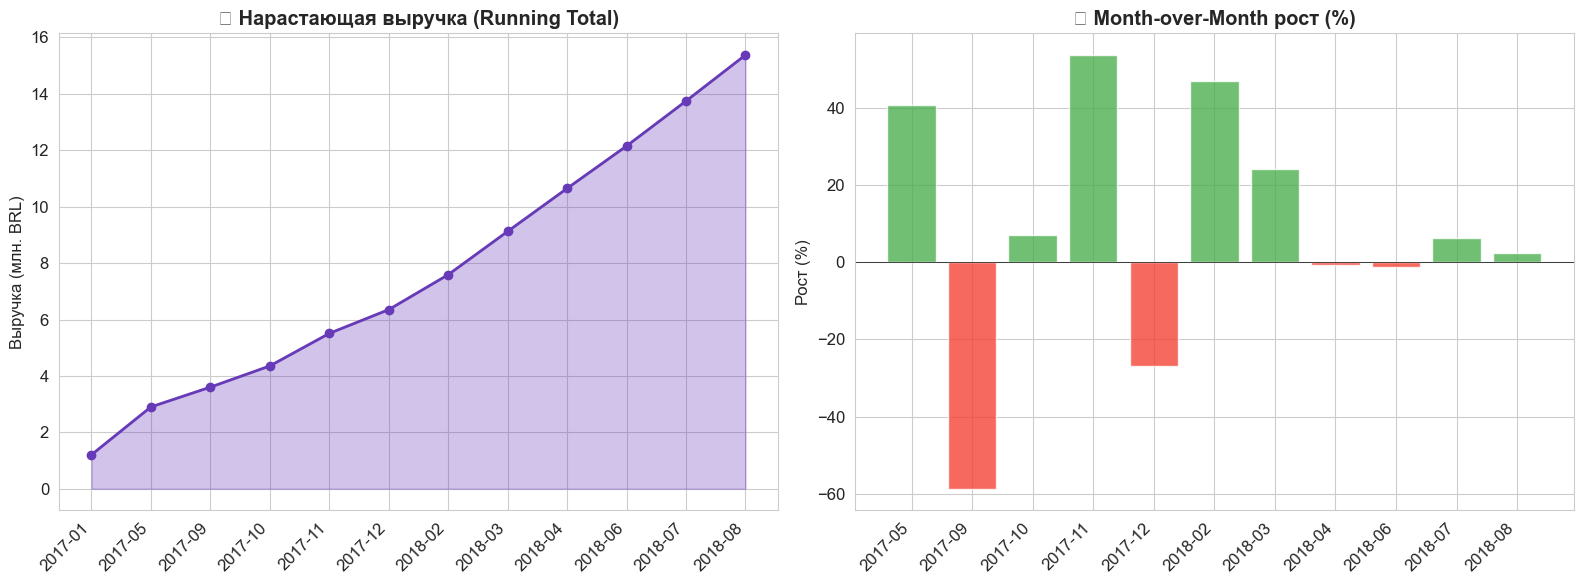

In [27]:
# Визуализация running total
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Running total
axes[0].fill_between(range(len(running_total)), running_total['running_total']/1e6, 
                     alpha=0.3, color='#673AB7')
axes[0].plot(range(len(running_total)), running_total['running_total']/1e6, 
             'o-', color='#673AB7', linewidth=2)
axes[0].set_xticks(range(len(running_total)))
axes[0].set_xticklabels(running_total['month'], rotation=45, ha='right')
axes[0].set_title('📈 Нарастающая выручка (Running Total)', fontweight='bold')
axes[0].set_ylabel('Выручка (млн. BRL)')

# MoM growth
mom = running_total['mom_growth_pct'].dropna()
colors_mom = ['#4CAF50' if x > 0 else '#f44336' for x in mom]
axes[1].bar(range(len(mom)), mom, color=colors_mom, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xticks(range(len(mom)))
axes[1].set_xticklabels(running_total['month'][1:], rotation=45, ha='right')
axes[1].set_title('📊 Month-over-Month рост (%)', fontweight='bold')
axes[1].set_ylabel('Рост (%)')

plt.tight_layout()
plt.savefig('charts/09_window_functions.png', dpi=150, bbox_inches='tight')
plt.show()